In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

file_path = "../data/final/DatasetfinaleMaugeri.xlsx"

df = pd.read_excel(file_path)

print("Dataset caricato")
print("Shape:", df.shape)

Dataset caricato
Shape: (195, 203)


In [6]:
df = df.dropna()

In [7]:
asy_cols = [c for c in df.columns if "ASY" in c]

len(asy_cols)

120

In [8]:
corr_matrix = df[asy_cols].corr(method="spearman")

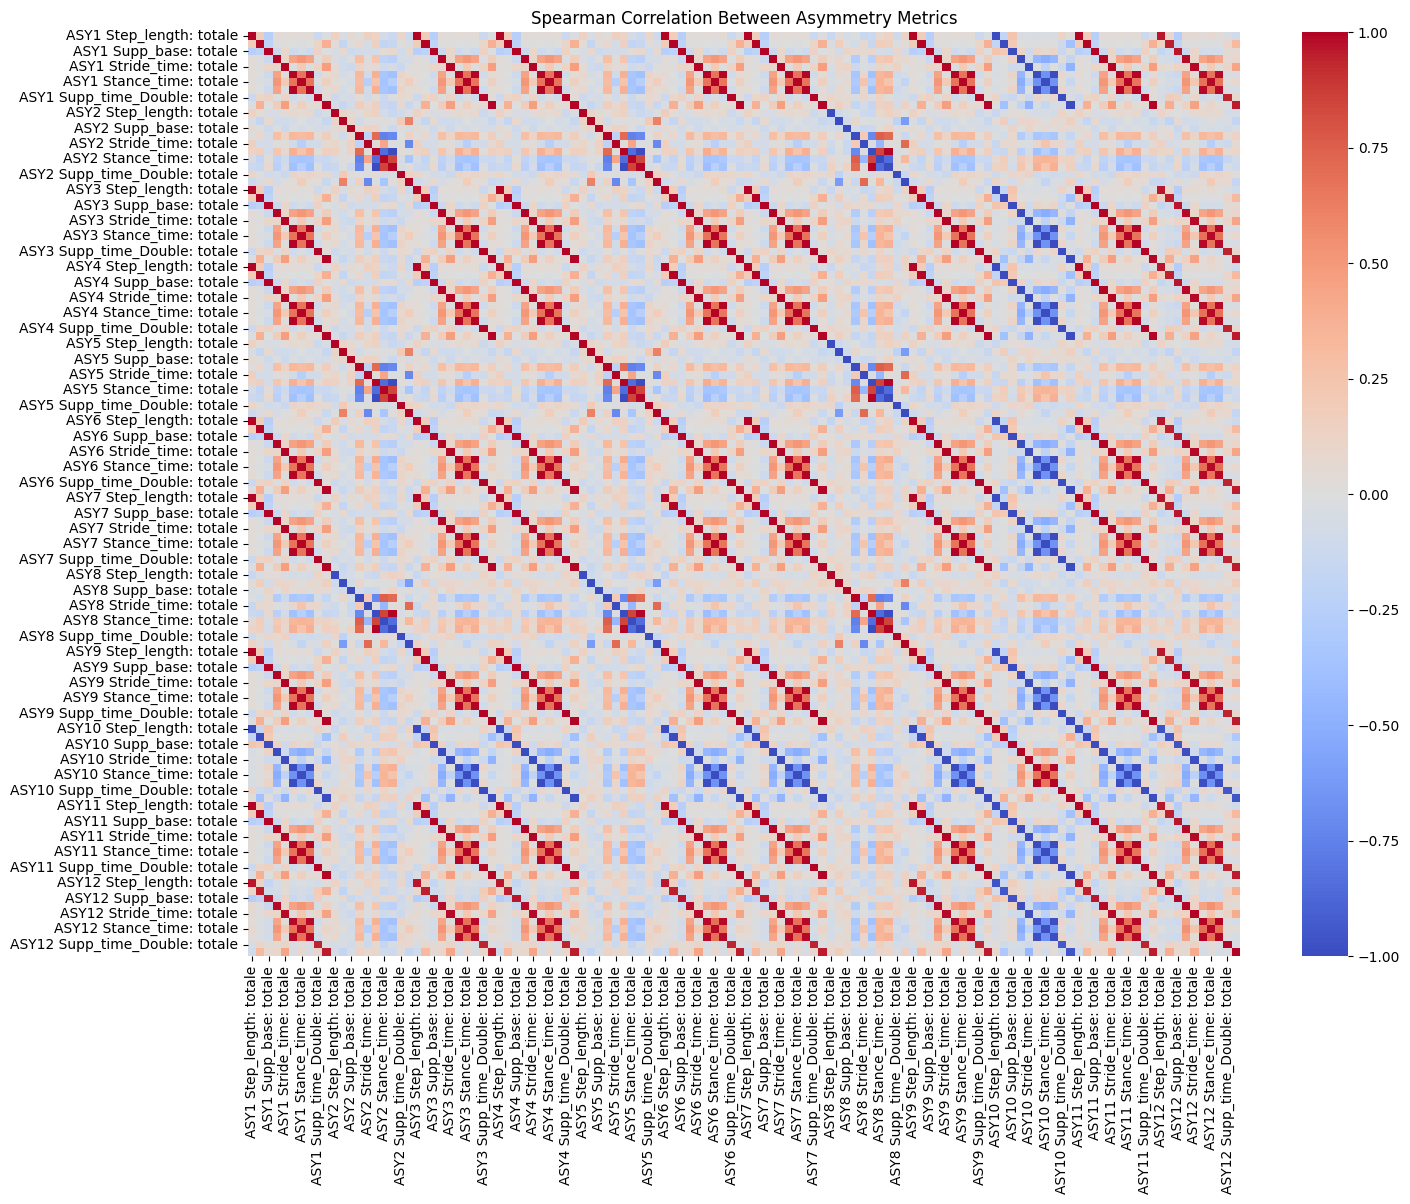

In [9]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Between Asymmetry Metrics")
plt.show()

In [10]:
formula_data = {}

for i in range(1,13):
    cols = [c for c in df.columns if c.startswith(f"ASY{i}")]
    formula_data[f"ASY{i}"] = df[cols].mean(axis=1)

formula_df = pd.DataFrame(formula_data)

formula_df.head()

,ASY1,ASY2,ASY3,ASY4,ASY5,ASY6,ASY7,ASY8,ASY9,ASY10,ASY11,ASY12
0,3.233742,0.981557,5.547321,5.543152,1.012234,5.608703,1.763118,-0.004902,0.027716,0.946840,5.543152,0.897654
1,2.428093,1.905583,4.041504,4.039551,1.020537,4.127591,1.285209,-0.009522,0.020198,0.961001,4.039551,0.670315
2,1.774849,1.694828,2.548664,2.545792,1.018220,2.669497,0.809443,-0.008460,0.012729,0.975670,2.545792,1.029271
3,2.146323,1.240383,3.332860,3.332284,1.013128,3.360145,1.060516,-0.006201,0.016661,0.967380,3.332284,0.952769
4,2.156224,-0.164472,3.609371,3.608105,0.999420,3.635029,1.148093,0.000825,0.018041,0.964938,3.608105,0.442483


In [11]:
corr_formulas = formula_df.corr(method="spearman")

corr_formulas

,ASY1,ASY2,ASY3,ASY4,ASY5,ASY6,ASY7,ASY8,ASY9,ASY10,ASY11,ASY12
ASY1,1.000000,0.074421,0.994912,0.994924,0.137649,0.993026,0.994841,-0.073855,0.994924,-0.993805,0.994924,0.503209
ASY2,0.074421,1.000000,0.060896,0.059609,0.993558,0.113039,0.059785,-0.999979,0.059609,-0.056751,0.059609,0.034864
ASY3,0.994912,0.060896,1.000000,0.999975,0.124715,0.997255,0.999941,-0.060406,0.999975,-0.999078,0.999975,0.436104
ASY4,0.994924,0.059609,0.999975,1.000000,0.123458,0.997062,0.999979,-0.059123,1.000000,-0.999170,1.000000,0.436243
ASY5,0.137649,0.993558,0.124715,0.123458,1.000000,0.176342,0.123533,-0.993453,0.123458,-0.120755,0.123458,0.036231
ASY6,0.993026,0.113039,0.997255,0.997062,0.176342,1.000000,0.997033,-0.112481,0.997062,-0.996140,0.997062,0.433346
ASY7,0.994841,0.059785,0.999941,0.999979,0.123533,0.997033,1.000000,-0.059295,0.999979,-0.999241,0.999979,0.435815
ASY8,-0.073855,-0.999979,-0.060406,-0.059123,-0.993453,-0.112481,-0.059295,1.000000,-0.059123,0.056260,-0.059123,-0.034403
ASY9,0.994924,0.059609,0.999975,1.000000,0.123458,0.997062,0.999979,-0.059123,1.000000,-0.999170,1.000000,0.436243
ASY10,-0.993805,-0.056751,-0.999078,-0.999170,-0.120755,-0.996140,-0.999241,0.056260,-0.999170,1.000000,-0.999170,-0.431322


In [12]:
corr_table = corr_formulas.round(3)

corr_table

,ASY1,ASY2,ASY3,ASY4,ASY5,ASY6,ASY7,ASY8,ASY9,ASY10,ASY11,ASY12
ASY1,1.000,0.074,0.995,0.995,0.138,0.993,0.995,-0.074,0.995,-0.994,0.995,0.503
ASY2,0.074,1.000,0.061,0.060,0.994,0.113,0.060,-1.000,0.060,-0.057,0.060,0.035
ASY3,0.995,0.061,1.000,1.000,0.125,0.997,1.000,-0.060,1.000,-0.999,1.000,0.436
ASY4,0.995,0.060,1.000,1.000,0.123,0.997,1.000,-0.059,1.000,-0.999,1.000,0.436
ASY5,0.138,0.994,0.125,0.123,1.000,0.176,0.124,-0.993,0.123,-0.121,0.123,0.036
ASY6,0.993,0.113,0.997,0.997,0.176,1.000,0.997,-0.112,0.997,-0.996,0.997,0.433
ASY7,0.995,0.060,1.000,1.000,0.124,0.997,1.000,-0.059,1.000,-0.999,1.000,0.436
ASY8,-0.074,-1.000,-0.060,-0.059,-0.993,-0.112,-0.059,1.000,-0.059,0.056,-0.059,-0.034
ASY9,0.995,0.060,1.000,1.000,0.123,0.997,1.000,-0.059,1.000,-0.999,1.000,0.436
ASY10,-0.994,-0.057,-0.999,-0.999,-0.121,-0.996,-0.999,0.056,-0.999,1.000,-0.999,-0.431


In [14]:
import os

# creare cartella results se non esiste
os.makedirs("../results", exist_ok=True)

# salvare la tabella
corr_table.to_excel("../results/correlation_asymmetry_formulas.xlsx")

print("Tabella salvata in ../results/")

Tabella salvata in ../results/


## PROVO A FARE PCA PER VEDERE COSA SUCCEDE

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
X = df[asy_cols]

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [19]:
explained_variance = pca.explained_variance_ratio_

for i,v in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {v:.3f}")

PC1: 0.323
PC2: 0.150
PC3: 0.098
PC4: 0.078
PC5: 0.069
PC6: 0.061
PC7: 0.048
PC8: 0.033
PC9: 0.028
PC10: 0.026


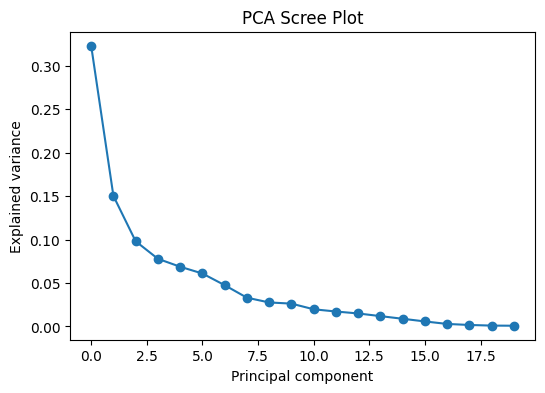

In [20]:
plt.figure(figsize=(6,4))

plt.plot(explained_variance[:20], marker="o")

plt.xlabel("Principal component")
plt.ylabel("Explained variance")

plt.title("PCA Scree Plot")

plt.show()

## Interpretazione della Scree Plot

Varianza spiegata:

PC	Varianza
PC1	0.323
PC2	0.150
PC3	0.098
PC4	0.078
PC5	0.069
PC6	0.061
Cumulativa

PC1 → 32%

PC1–2 → 47%

PC1–3 → 57%

PC1–5 → 72%

PC1–10 → ≈88%

Interpretazione

Questo significa che:

le 120 metriche non sono indipendenti

ma si organizzano in poche dimensioni latenti.

In pratica:

PC1 cattura la magnitudine dell’asimmetria

PC2 cattura il segno delle metriche (signed vs absolute)

PC3–PC6 catturano differenze matematiche tra famiglie

Questo è coerente con la correlazione che avevi visto.

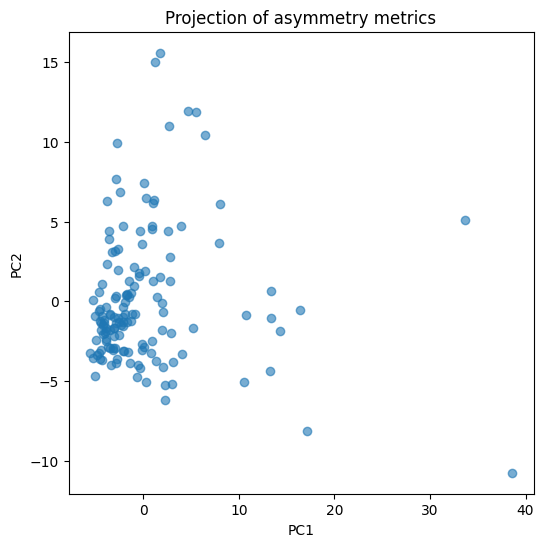

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Projection of asymmetry metrics")

plt.show()

## Interpretazione della proiezione PC1–PC2

Il grafico mostra:

una nuvola centrale compatta

pochi outlier con alta asimmetria

Interpretazione clinica:

la maggior parte dei soggetti ha bassa asimmetria
mentre pochi mostrano asimmetria molto elevata

Questo è tipico nel Parkinson.

Probabilmente quei punti a destra sono:

H&Y 3

oppure soggetti con forte lateralizzazione.

In [22]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=asy_cols
)

In [23]:
loadings["formula"] = [c.split()[0] for c in asy_cols]

In [24]:
formula_loadings = loadings.groupby("formula").mean()

In [25]:
from sklearn.decomposition import PCA

pca_load = PCA(n_components=2)

formula_pca = pca_load.fit_transform(formula_loadings)

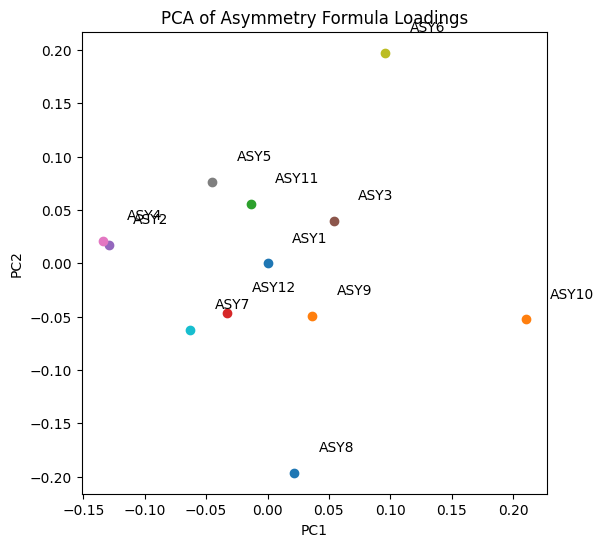

In [26]:
plt.figure(figsize=(6,6))

for i,formula in enumerate(formula_loadings.index):

    plt.scatter(
        formula_pca[i,0],
        formula_pca[i,1]
    )

    plt.text(
        formula_pca[i,0]+0.02,
        formula_pca[i,1]+0.02,
        formula
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA of Asymmetry Formula Loadings")

plt.show()

## Cosa mostra la PCA dei loadings

Questa PCA non è sui soggetti, ma sulle formule di asimmetria.

Quindi ogni punto nel grafico rappresenta:

una formula (ASY1–ASY12)

e la sua posizione dipende da come contribuisce alle componenti principali derivate dalle 120 metriche.

In pratica stai osservando:

la struttura matematica delle formule

Struttura che emerge

Dal grafico si vedono tre regioni principali.

Cluster principale

Molte formule sono molto vicine:

ASY1
ASY3
ASY4
ASY7
ASY9
ASY11

Questo è coerente con la correlazione ~0.99 che avevi trovato.

Interpretazione:

queste formule sono praticamente equivalenti

misurano tutte la magnitudine dell’asimmetria.

Cluster ratio

Più distanti troviamo:

ASY5
ASY6
ASY8

Queste formule derivano dal rapporto tra i lati e introducono trasformazioni non lineari.

In particolare:

ASY8 è separata lungo PC2

segno della metrica invertito

Outlier

Molto separata appare:

ASY10

che è:

min(L,R)/max(L,R)

Questa metrica comprime i valori verso 1 e quindi produce una distribuzione diversa.

Significato delle componenti

PC1

PC1 rappresenta probabilmente:

scala di misura dell’asimmetria

cioè quanto una formula amplifica o comprime le differenze tra i lati.

PC2

PC2 rappresenta probabilmente:

proprietà matematiche della formula

come:

trasformazioni logaritmiche

simmetria

normalizzazione

Cosa dimostra scientificamente

Questo risultato dimostra che:

la maggior parte delle formule non introduce nuove informazioni

ma sono varianti matematiche dello stesso costrutto.

Quindi la proliferazione di metriche nella letteratura è:

ridondante

Frase eventuale per un paper

Potresti scrivere qualcosa del tipo:

Principal component analysis of the asymmetry formula loadings revealed clear clustering among the metrics. Several formulations (ASY1, ASY3, ASY4, ASY7, ASY9, ASY11) occupied nearly identical regions in the latent space, indicating strong mathematical redundancy. Ratio-based formulations (ASY5, ASY6, ASY8) formed a separate cluster, while the min/max ratio (ASY10) appeared as a distinct outlier. These results confirm that many asymmetry indices represent alternative mathematical expressions of the same underlying construct.

## DENDOGRAMMA

In [28]:
corr_formulas

,ASY1,ASY2,ASY3,ASY4,ASY5,ASY6,ASY7,ASY8,ASY9,ASY10,ASY11,ASY12
ASY1,1.000000,0.074421,0.994912,0.994924,0.137649,0.993026,0.994841,-0.073855,0.994924,-0.993805,0.994924,0.503209
ASY2,0.074421,1.000000,0.060896,0.059609,0.993558,0.113039,0.059785,-0.999979,0.059609,-0.056751,0.059609,0.034864
ASY3,0.994912,0.060896,1.000000,0.999975,0.124715,0.997255,0.999941,-0.060406,0.999975,-0.999078,0.999975,0.436104
ASY4,0.994924,0.059609,0.999975,1.000000,0.123458,0.997062,0.999979,-0.059123,1.000000,-0.999170,1.000000,0.436243
ASY5,0.137649,0.993558,0.124715,0.123458,1.000000,0.176342,0.123533,-0.993453,0.123458,-0.120755,0.123458,0.036231
ASY6,0.993026,0.113039,0.997255,0.997062,0.176342,1.000000,0.997033,-0.112481,0.997062,-0.996140,0.997062,0.433346
ASY7,0.994841,0.059785,0.999941,0.999979,0.123533,0.997033,1.000000,-0.059295,0.999979,-0.999241,0.999979,0.435815
ASY8,-0.073855,-0.999979,-0.060406,-0.059123,-0.993453,-0.112481,-0.059295,1.000000,-0.059123,0.056260,-0.059123,-0.034403
ASY9,0.994924,0.059609,0.999975,1.000000,0.123458,0.997062,0.999979,-0.059123,1.000000,-0.999170,1.000000,0.436243
ASY10,-0.993805,-0.056751,-0.999078,-0.999170,-0.120755,-0.996140,-0.999241,0.056260,-0.999170,1.000000,-0.999170,-0.431322


In [29]:
import numpy as np

distance_matrix = 1 - np.abs(corr_formulas)

In [30]:
from scipy.spatial.distance import squareform

dist_condensed = squareform(distance_matrix)

In [31]:
from scipy.cluster.hierarchy import linkage

Z = linkage(dist_condensed, method="average")

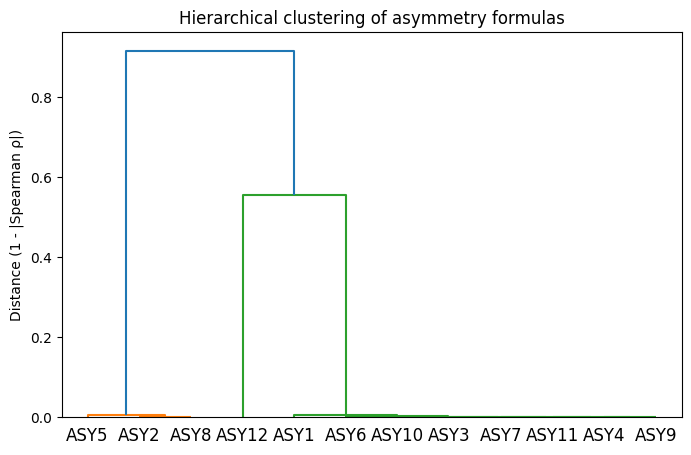

In [32]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

dendrogram(
    Z,
    labels=corr_formulas.columns
)

plt.title("Hierarchical clustering of asymmetry formulas")
plt.ylabel("Distance (1 - |Spearman ρ|)")

plt.show()

1️⃣ Come leggere l’asse Y

L’asse verticale è:

Distance = 1 − |Spearman ρ|

Quindi:

distanza	interpretazione
0	formule praticamente identiche
0.1	quasi equivalenti
0.5	moderatamente diverse
>0.8	strutturalmente diverse

2️⃣ Primo cluster (ratio-based)

Il cluster più separato è:

ASY5
ASY2
ASY8

Queste formule condividono la stessa struttura matematica:

ASY5 = L/R

ASY2 = ln(L/R)

ASY8 = (R−L)/(R+L)

Tutte descrivono asimmetria signed (con direzione).

Questo cluster si separa subito perché:

non usano valore assoluto

quindi mantengono l'informazione sul lato dominante.

3️⃣ Secondo cluster principale

Il grande cluster include:

ASY1
ASY6
ASY10
ASY3
ASY7
ASY11
ASY4
ASY9

Queste metriche condividono una proprietà:

misurano la magnitudine dell’asimmetria

senza informazione direzionale.

Sono tutte:

normalizzate

absolute

simmetriche L/R

Quindi è normale che risultino quasi indistinguibili.

4️⃣ Posizione di ASY12
ASY12 = |L − R|

È una differenza assoluta non normalizzata.

Per questo si colloca tra i due gruppi:
non è completamente equivalente alle altre metriche.

5️⃣ Coerenza con le analisi precedenti

Il dendrogramma conferma perfettamente:

matrice di correlazione
ρ ≈ 0.99

tra molte formule.

PCA loadings

cluster molto vicini tra:

ASY1
ASY3
ASY4
ASY7
ASY9
ASY11
struttura matematica

le formule si organizzano in due famiglie principali:

famiglia	proprietà
signed ratio	direzione dell’asimmetria
magnitude indices	magnitudine dell’asimmetria

6️⃣ Interpretazione metodologica

Questo risultato dimostra che:

la maggior parte degli indici di asimmetria sono matematicamente ridondanti

cioè:

formule diverse → stessa informazione

La proliferazione di metriche nella letteratura è quindi più storica che metodologica.

7️⃣ Frase per Results

Puoi scrivere:

Hierarchical clustering based on absolute Spearman correlations revealed two main groups of asymmetry indices. A first cluster included signed ratio-based formulations (ASY2, ASY5, ASY8), which preserve the direction of asymmetry. A larger cluster comprised indices capturing the magnitude of asymmetry (ASY1, ASY3, ASY4, ASY6, ASY7, ASY9, ASY10, ASY11), which were nearly indistinguishable in terms of mathematical behaviour. The simple absolute difference (ASY12) occupied an intermediate position. These findings confirm the substantial redundancy among commonly used asymmetry metrics.

8️⃣ Dove siamo nel workflow del paper

Abbiamo completato la parte metodologica:

Notebook 01

dataset overview

Notebook 02

struttura matematica delle metriche

correlazioni

PCA

PCA loadings

dendrogramma

Questa parte dimostra:

le metriche sono ridondanti